In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [2]:
df = pd.read_csv(r"D:\ML\Scikit-Learn-Tutorial-\New ML\placement (1).csv")
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


<Axes: xlabel='placement_exam_marks', ylabel='Count'>

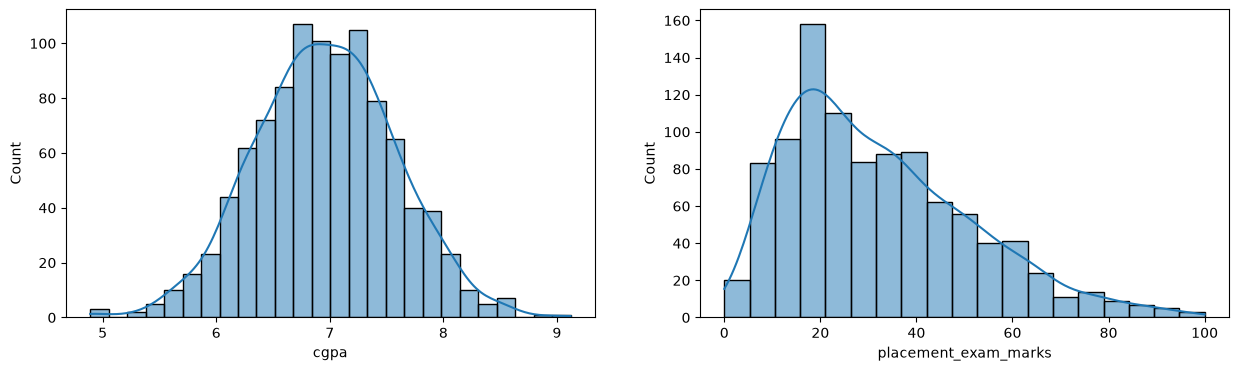

In [4]:
plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

In [5]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [7]:
percentile25  = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
print(percentile25)
print(percentile75)

17.0
44.0


In [8]:
# iqr 
iqr = percentile75 - percentile25

In [9]:
upper_limit = percentile75 + 1.5* iqr
lower_limit = percentile25 - 1.5* iqr
print(upper_limit)
print(lower_limit)

84.5
-23.5


In [11]:
df[df['placement_exam_marks']>upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [12]:
df[df['placement_exam_marks']<lower_limit]

,cgpa,placement_exam_marks,placed


In [14]:
new_df = df[df['placement_exam_marks']<upper_limit]
new_df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [15]:
new_df.shape

(985, 3)

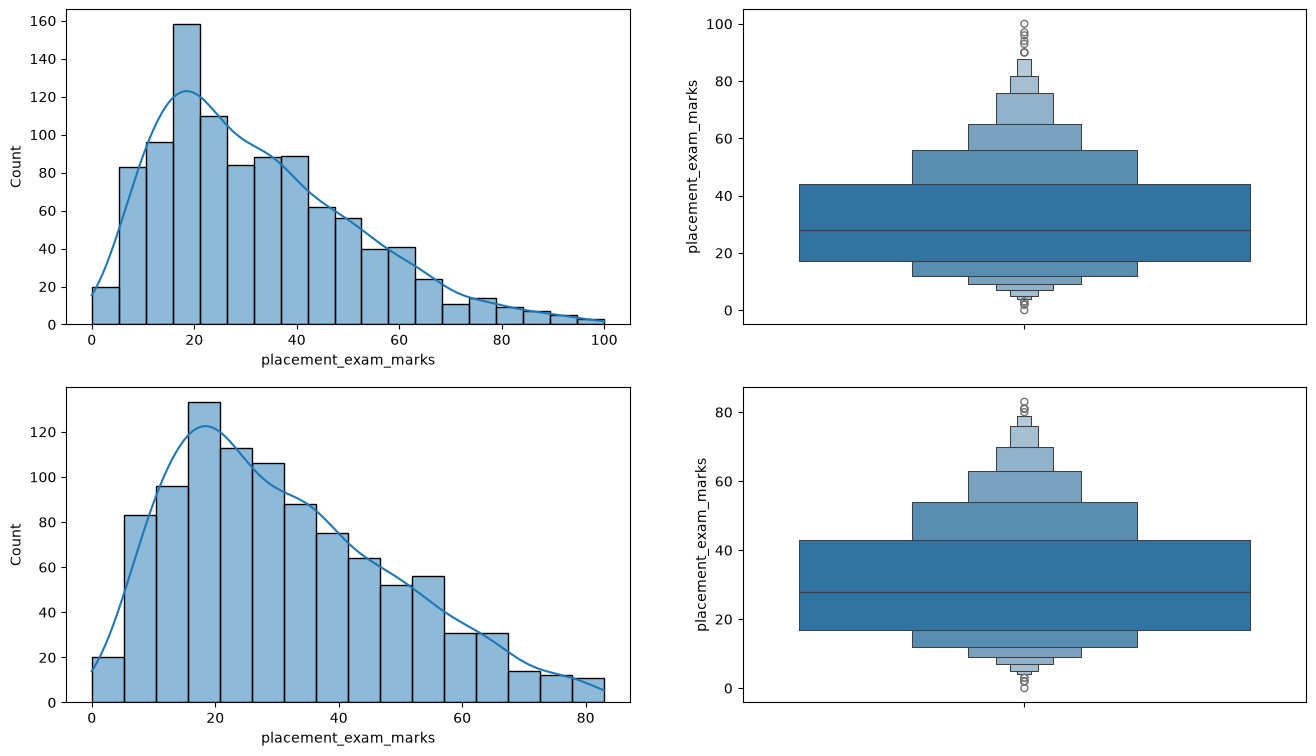

In [21]:
# comparing
plt.figure(figsize=(16,9))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.subplot(2,2,2)
sns.boxenplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'], kde=True)
plt.subplot(2,2,4)
sns.boxenplot(new_df['placement_exam_marks'])
plt.show()

In [26]:
# handling outlier by capping
new_df_cap = df.copy()
new_df_cap.shape

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks']> upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [27]:
new_df_cap.shape

(1000, 3)

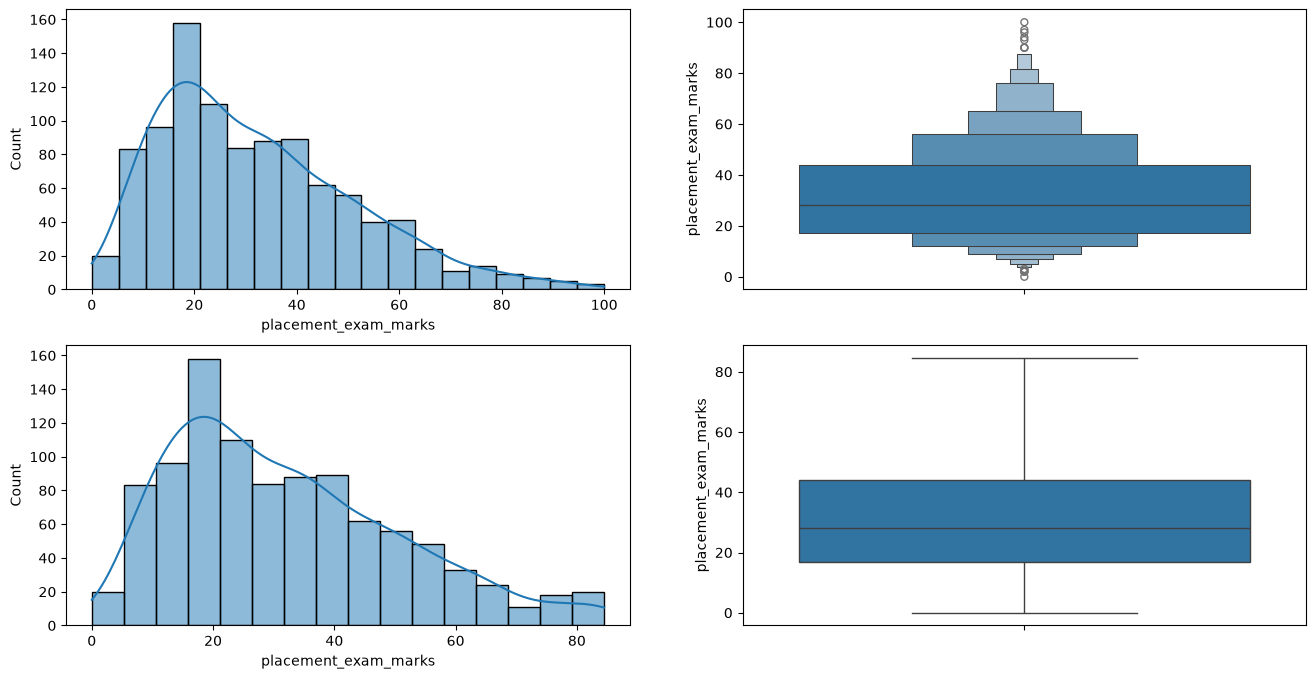

In [29]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.subplot(2,2,2)
sns.boxenplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'], kde=True)
plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()